In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [37]:
df_3_washout = pd.read_csv('C:/Users/jacob/water_current_MA/data/dual_generalization/washout/df_washout_3.csv')
df_2_washout = pd.read_csv('C:/Users/jacob/water_current_MA/data/dual_generalization/washout/df_washout_2.csv')

# combine df and add a column  to d
df_combined = pd.concat([
    df_3_washout.assign(task_water_speed=3.0),
    df_2_washout.assign(task_water_speed=2.0)
]).astype({"task_water_speed": "category"})


# final variable type declarations
water_speed_order = pd.CategoricalDtype(categories=[3.0,2.0], ordered=True)
df_combined['task_water_speed'] = df_combined['task_water_speed'].astype(water_speed_order)

target_order = pd.CategoricalDtype(categories=['L60','L30','R30','R60'], ordered=True)
df_combined['target_id'] = df_combined['target_id'].astype(target_order)

block_order = pd.CategoricalDtype(categories=[1, 2, 3, 4, 5, -1], ordered=True)
df_combined['block_num'] = df_combined['block_num'].astype(block_order)


# add a new boolean column logging if trial average is larger than baseline (upper CI OR upper tail) & within Training CI
df_combined['beyond_baseline_ci_in_training_ci'] = df_combined['baseline_ci_aftereffect'] & df_combined['inside_training_ci']
df_combined['beyond_baseline_dist_in_training_ci'] = df_combined['baseline_dist_aftereffect'] & df_combined['inside_training_ci']


print(df_combined.info())
df_combined.head(16)



<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, 0 to 191
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   block_num                            384 non-null    category
 1   trial_in_block                       384 non-null    int64   
 2   target_id                            384 non-null    category
 3   mean_dev                             384 non-null    float64 
 4   baseline_ci_threshold_high           384 non-null    float64 
 5   baseline_ci_aftereffect              384 non-null    bool    
 6   training_ci_low                      384 non-null    float64 
 7   training_ci_high                     384 non-null    float64 
 8   inside_training_ci                   384 non-null    bool    
 9   baseline_sigma_high                  384 non-null    float64 
 10  baseline_sigma_low                   384 non-null    float64 
 11  baseline_dist_aftereffec

,block_num,trial_in_block,target_id,mean_dev,baseline_ci_threshold_high,baseline_ci_aftereffect,training_ci_low,training_ci_high,inside_training_ci,baseline_sigma_high,baseline_sigma_low,baseline_dist_aftereffect,task_water_speed,beyond_baseline_ci_in_training_ci,beyond_baseline_dist_in_training_ci
0,1,1,L60,37.21,2.33,True,28.11,57.22,True,9.39,-10.52,True,3.0,True,True
1,1,1,L30,18.02,2.62,True,18.96,40.07,False,10.05,-10.60,True,3.0,False,False
2,1,1,R30,15.94,2.33,True,10.06,32.03,True,9.14,-10.18,True,3.0,True,True
3,1,1,R60,6.40,2.67,True,-0.94,16.75,True,9.42,-9.50,False,3.0,True,False
4,1,2,L60,12.17,2.33,True,28.11,57.22,False,9.39,-10.52,True,3.0,False,False
5,1,2,L30,1.59,2.62,False,18.96,40.07,False,10.05,-10.60,False,3.0,False,False
6,1,2,R30,3.65,2.33,True,10.06,32.03,False,9.14,-10.18,False,3.0,False,False
7,1,2,R60,2.75,2.67,True,-0.94,16.75,True,9.42,-9.50,False,3.0,True,False
8,1,3,L60,5.10,2.33,True,28.11,57.22,False,9.39,-10.52,False,3.0,False,False
9,1,3,L30,1.08,2.62,False,18.96,40.07,False,10.05,-10.60,False,3.0,False,False


Plotting functions:

In [33]:

def plot_aftereffects(data,
                      facet_col = 'block_num',
                      facet_row = 'task_water_speed',
                      target_col = 'target_id',
                      marker_variable_list = ['baseline_ci_aftereffect','inside_training_ci'],
                      x_col = 'trial_in_block',
                      y_col = 'target_id'
                     ):

    # colours
    _colors = sns.color_palette(["#FF0000", "#0000FF", "#FF4500", "#05472A"])
    TARGET_PALETTE = {
        "L60": _colors[3], # Green
        "L30": _colors[2], # Blue
        "R30": _colors[1], # Orange
        "R60": _colors[0]  # Red
    }

    # setup plot
    g = sns.FacetGrid(data=df_combined, col=facet_col, row=facet_row)
    
    # first layer: show hollow circle if aftereffect beyond baseline
    g.map_dataframe(
        sns.scatterplot, 
        x='trial_in_block', 
        y='target_id', 
        edgecolors=df_combined[target_col].astype(str).map(TARGET_PALETTE),
        facecolors='none',             
        linewidth=1.5,                  
        size=marker_variable_list[0],
        sizes={True: 100, False: 0}, 
        legend=False
    )
    
    # second layer: add star if mean launch dev is within stable T1 99% CI
    g.map_dataframe(
        sns.scatterplot, 
        x='trial_in_block', 
        y='target_id', 
        edgecolors=df_combined[target_col].astype(str).map(TARGET_PALETTE),
        facecolors='none',             
        linewidth=1.5,                  
        size=marker_variable_list[1],
        style=marker_variable_list[1],
        markers = {True: "*",
                   False: "."},
        sizes={True: 100, False: 0}, 
        legend=False
    )


def washout_lines(data,
                  x_col = 'trial_in_block',
                  y_col = 'mean_dev',
                  target_col = 'target_id',
                  marker_variable_list = ['baseline_ci_aftereffect','beyond_baseline_ci_in_training_ci'],
                 ):
        
    # facet
    g = sns.FacetGrid(data=df_combined, col='block_num', row='task_water_speed')
    
    # palette
    _colors = sns.color_palette(["#FF0000", "#0000FF", "#FF4500", "#05472A"])
    TARGET_PALETTE = {
            "L60": _colors[3], # Green
            "L30": _colors[2], # Blue
            "R30": _colors[1], # Orange
            "R60": _colors[0]  # Red
        }
    
    # first layer: average dev lines / target
    g.map_dataframe(
        sns.lineplot, data = data,
               x=x_col, y = y_col,
               hue=target_col, palette = TARGET_PALETTE, alpha = 0.3
    )

    # second layer: add hollow circle if marker_variable_list[0] is TRUE, ADD O
    g.map_dataframe(
        sns.scatterplot, 
        x=x_col, 
        y=y_col, 
        edgecolors=df_combined[target_col].astype(str).map(TARGET_PALETTE),
        facecolors='none',             
        linewidth=1.5,                  
        size=marker_variable_list[0],
        sizes={True: 100, False: 0}, 
        legend=False
    )
    

    

    # third layer: add star if marker_variable_list[1] is TRUE, ADD *
    g.map_dataframe(
        sns.scatterplot,
        x=x_col, 
        y=y_col,
        edgecolors=df_combined[target_col].astype(str).map(TARGET_PALETTE),
        facecolors='none',             
        linewidth=1.5,                  
        size=marker_variable_list[1],
        style=marker_variable_list[1],
        markers = {True: "*",
                   False: "."},
        sizes={True: 100, False: 0}, 
        legend=False
    )
        
    
    # add legend
    g.add_legend(title=target_col)


# Comparing Washout trial averages to upper baseline CI / target

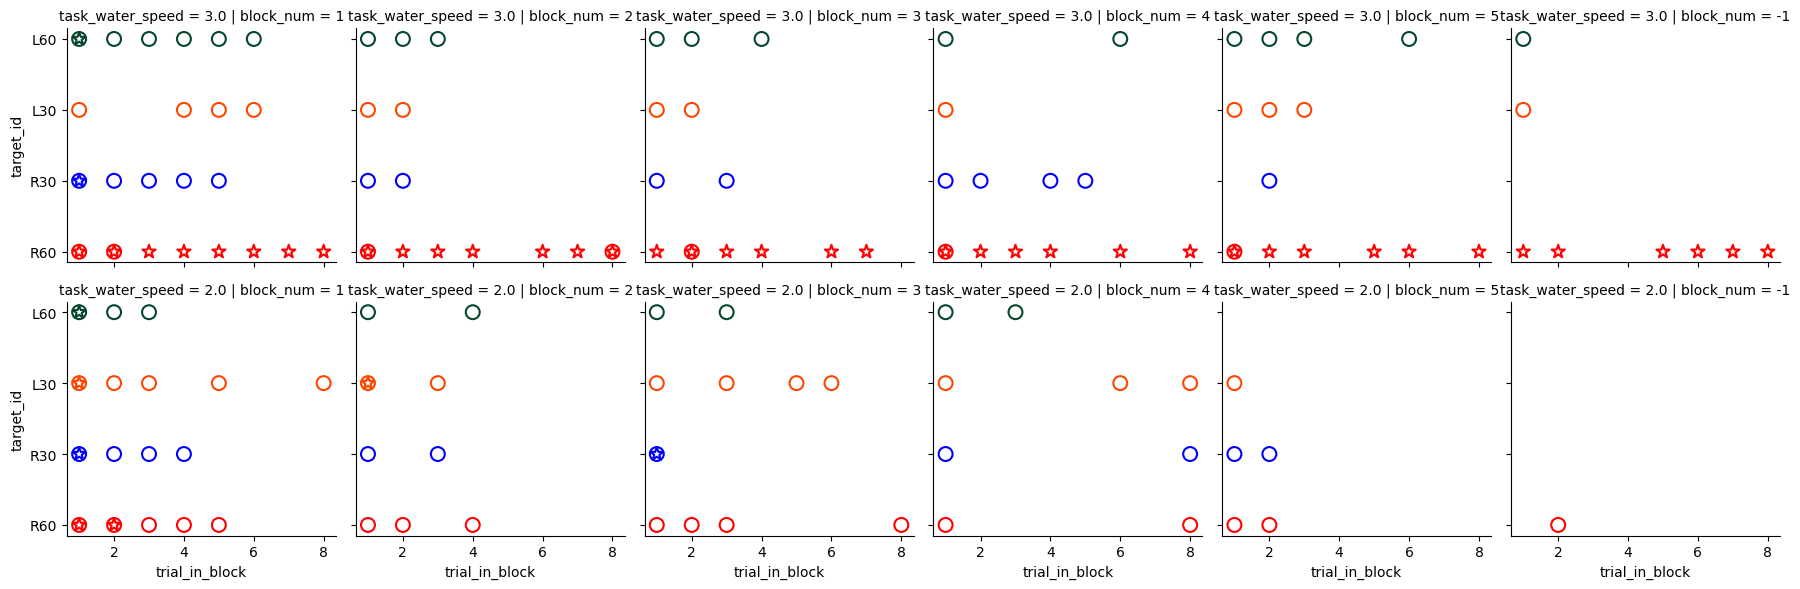

In [15]:
plot_aftereffects(data = df_combined)

# Comparing Washout trial averages to upper tail of baseline distribution / target

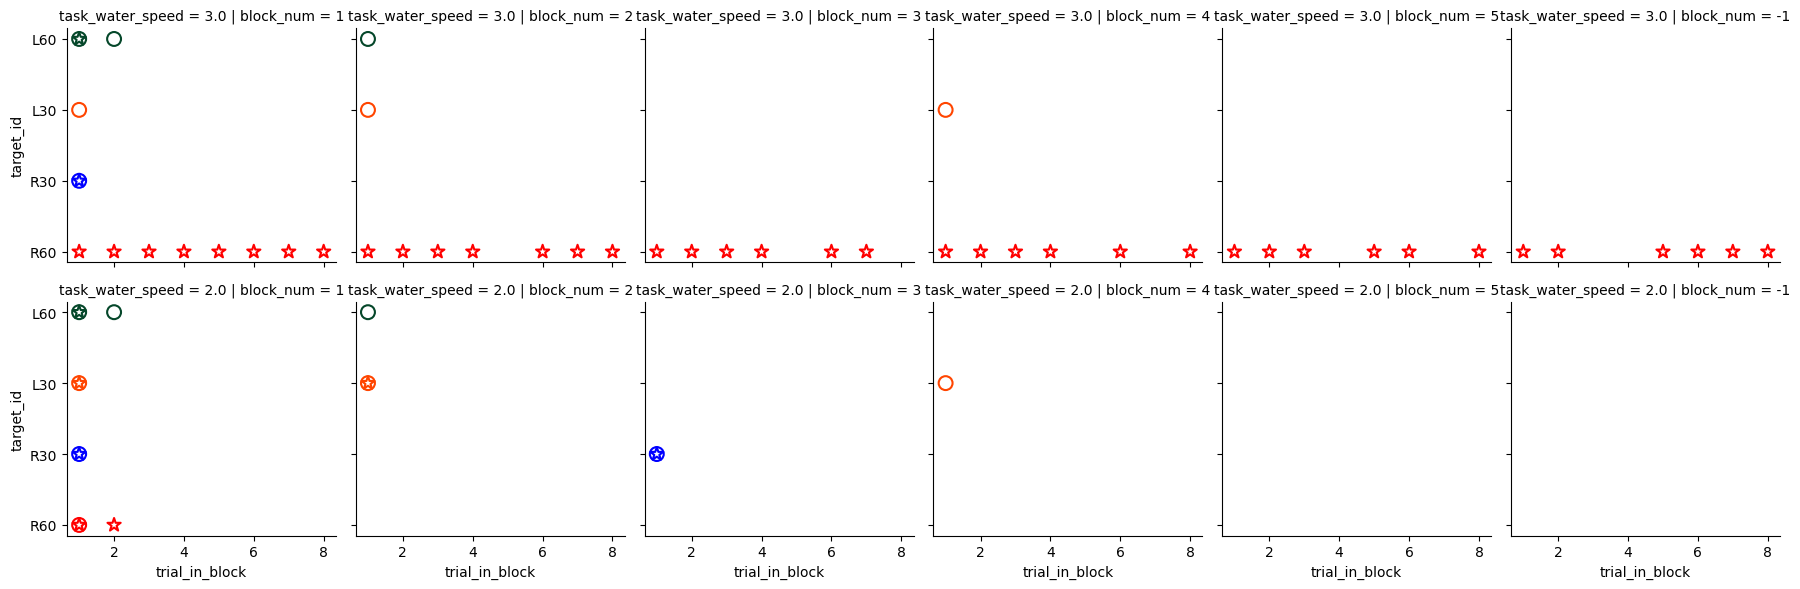

In [17]:
plot_aftereffects(data = df_combined,
                  marker_variable_list=['baseline_dist_aftereffect','inside_training_ci'])

Combining above plots with a line plot of trial averages across each block

# Upper Baseline CI vs Washout Trial Averages / Target

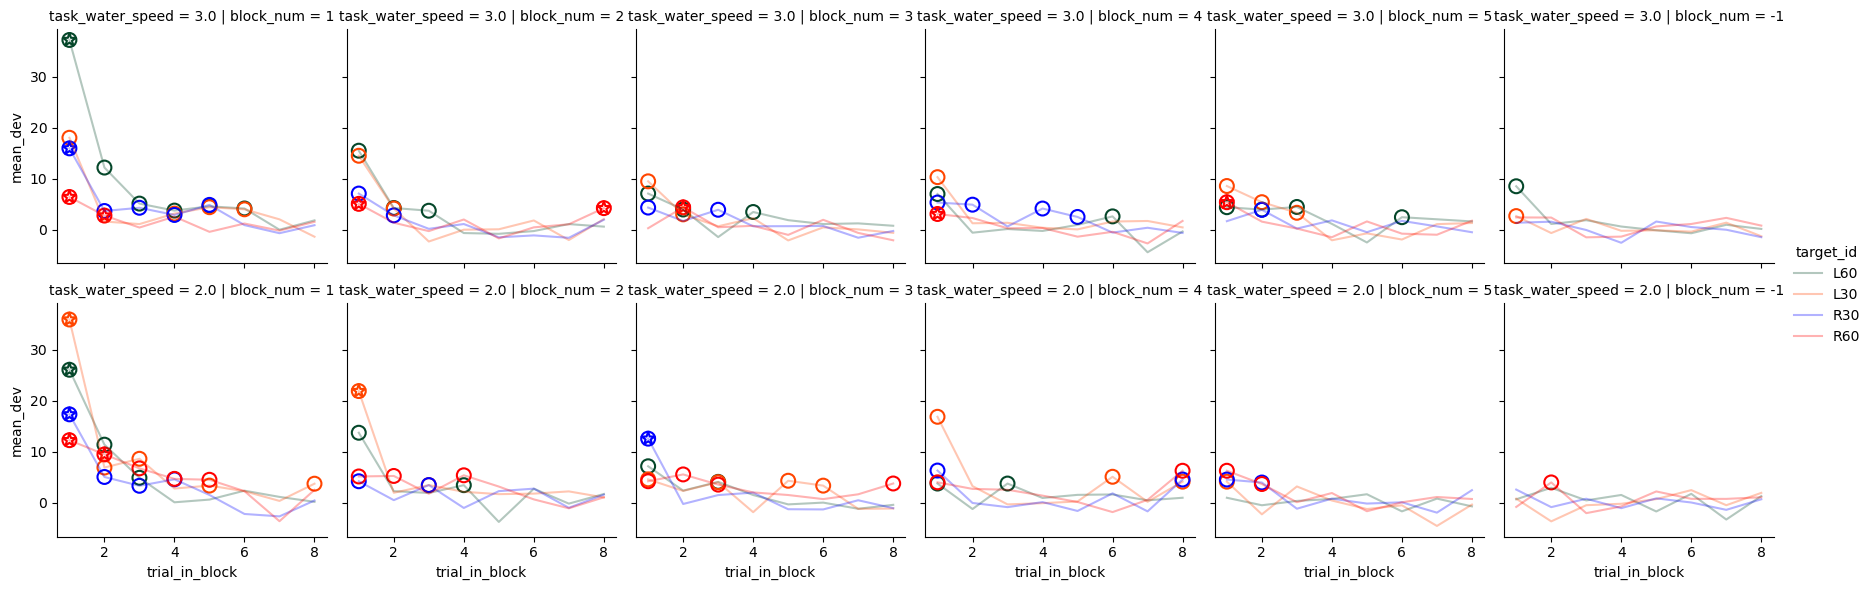

In [35]:
washout_lines(data=df_combined)

# Upper Tail from Baseline Distributions vs Washout Trial Averages / Target

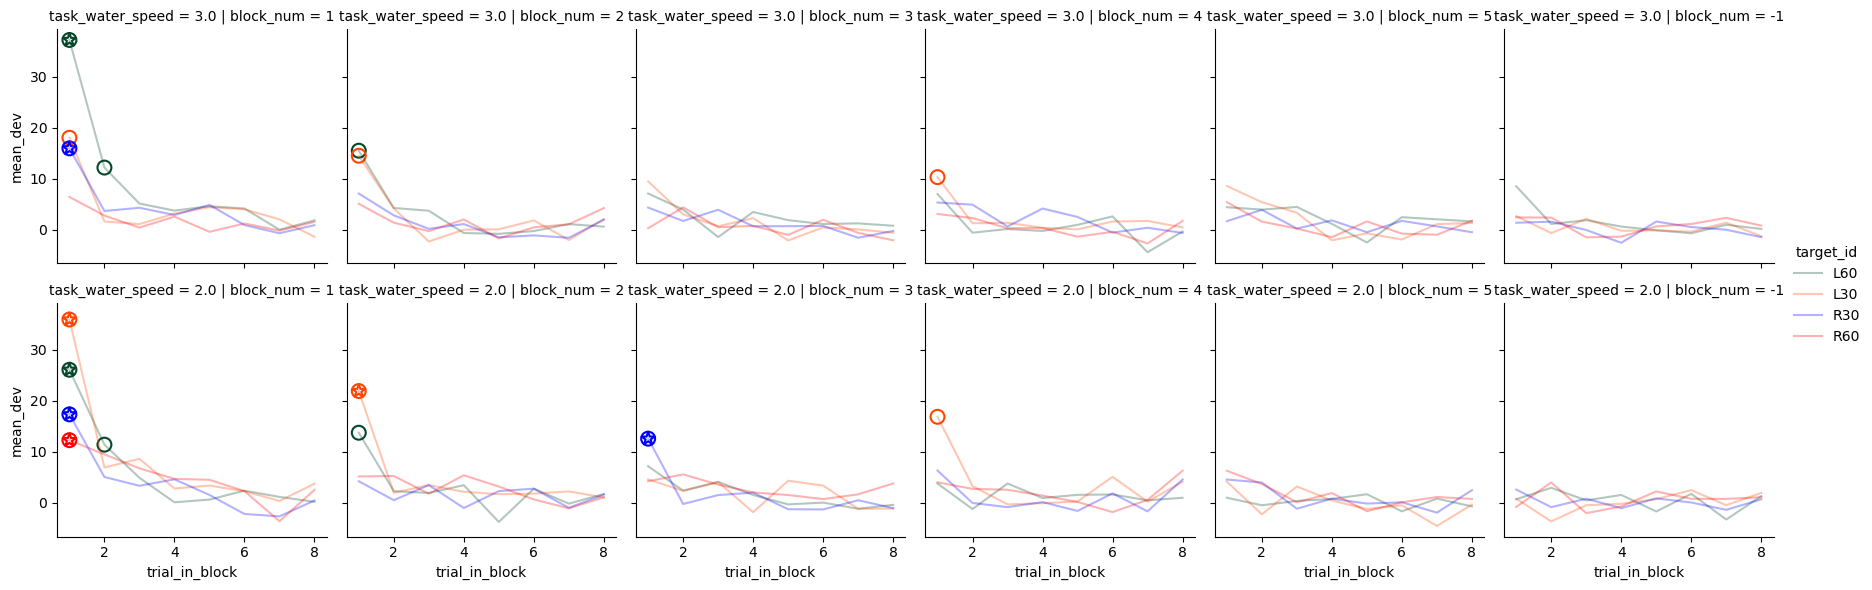

In [41]:
washout_lines(data=df_combined,
              marker_variable_list = ['baseline_dist_aftereffect','beyond_baseline_dist_in_training_ci'])